In [1]:
# azureml-core of version 1.0.72 or higher is required
# azureml-dataprep[pandas] of version 1.1.34 or higher is required
from azureml.core import Workspace, Dataset

subscription_id = '56937815-5290-4197-85cc-2de312d064c5'
resource_group = 'cmr'
workspace_name = 'cmrmlops'

workspace = Workspace(subscription_id, resource_group, workspace_name)

dataset = Dataset.get_by_name(workspace, name='Advanced_House_Price_Regression_Analysis')
dataset.to_pandas_dataframe()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,House_ID,Area_sqft,Bedrooms,Bathrooms,Floors,Age_of_House,Distance_to_City_km,Nearby_Schools,Parking_Spaces,Crime_Rate,House_Price
0,1,1200,2,2,1,10,8,3,1,2,4500000
1,2,1500,3,2,2,5,5,4,2,1,6200000
2,3,900,2,1,1,15,12,2,1,3,3000000
3,4,2000,4,3,2,2,3,5,2,1,8800000
4,5,1700,3,2,2,7,6,4,2,2,7000000
5,6,1100,2,2,1,12,10,3,1,3,4200000
6,7,2500,4,3,3,1,2,5,3,1,12000000
7,8,1300,3,2,1,8,7,4,2,2,5400000
8,9,800,1,1,1,20,15,2,0,4,2500000
9,10,2200,4,3,2,3,4,5,2,1,9500000


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
import warnings
warnings.filterwarnings("ignore")

from azureml.core import Workspace, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [3]:
from azureml.core import Workspace, Dataset

ws = Workspace.from_config()
dataset = Dataset.get_by_name(ws, name="Advanced_House_Price_Regression_Analysis")
df = dataset.to_pandas_dataframe()

df.head()

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,House_ID,Area_sqft,Bedrooms,Bathrooms,Floors,Age_of_House,Distance_to_City_km,Nearby_Schools,Parking_Spaces,Crime_Rate,House_Price
0,1,1200,2,2,1,10,8,3,1,2,4500000
1,2,1500,3,2,2,5,5,4,2,1,6200000
2,3,900,2,1,1,15,12,2,1,3,3000000
3,4,2000,4,3,2,2,3,5,2,1,8800000
4,5,1700,3,2,2,7,6,4,2,2,7000000


In [4]:
print("Dataset loaded successfully\n")
print(df.head())


Dataset loaded successfully

   House_ID  Area_sqft  Bedrooms  Bathrooms  Floors  Age_of_House  \
0         1       1200         2          2       1            10   
1         2       1500         3          2       2             5   
2         3        900         2          1       1            15   
3         4       2000         4          3       2             2   
4         5       1700         3          2       2             7   

   Distance_to_City_km  Nearby_Schools  Parking_Spaces  Crime_Rate  \
0                    8               3               1           2   
1                    5               4               2           1   
2                   12               2               1           3   
3                    3               5               2           1   
4                    6               4               2           2   

   House_Price  
0      4500000  
1      6200000  
2      3000000  
3      8800000  
4      7000000  


In [5]:
print("\n--- Basic Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

target = "House_Price"
features = [c for c in df.columns if c != target]



--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   House_ID             20 non-null     int64
 1   Area_sqft            20 non-null     int64
 2   Bedrooms             20 non-null     int64
 3   Bathrooms            20 non-null     int64
 4   Floors               20 non-null     int64
 5   Age_of_House         20 non-null     int64
 6   Distance_to_City_km  20 non-null     int64
 7   Nearby_Schools       20 non-null     int64
 8   Parking_Spaces       20 non-null     int64
 9   Crime_Rate           20 non-null     int64
 10  House_Price          20 non-null     int64
dtypes: int64(11)
memory usage: 1.8 KB
None

--- Statistical Summary ---
       House_ID    Area_sqft  Bedrooms  Bathrooms     Floors  Age_of_House  \
count  20.00000    20.000000  20.00000   20.00000  20.000000     20.000000   
mean   10.50000  1565.00

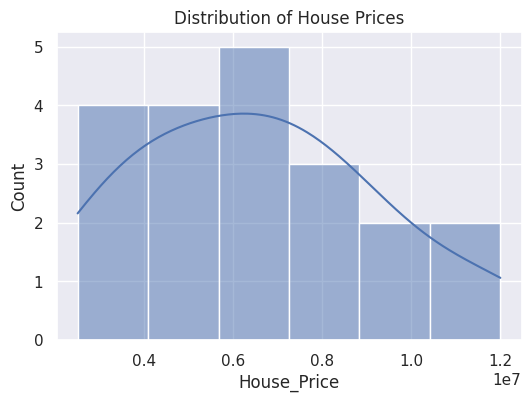

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df[target], kde=True)
plt.title("Distribution of House Prices")
plt.show()


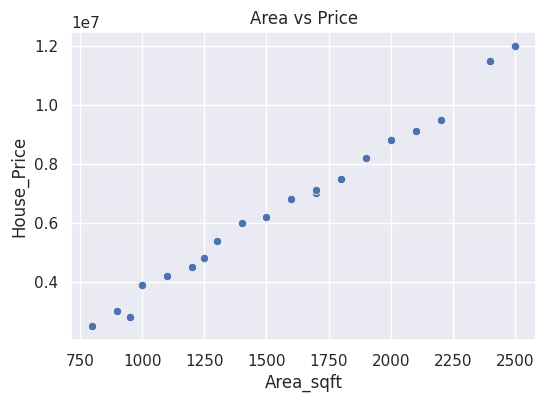

In [7]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Area_sqft"], y=df[target])
plt.title("Area vs Price")
plt.show()

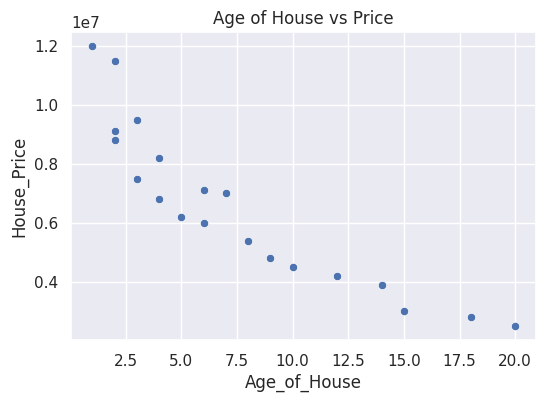

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Age_of_House"], y=df[target])
plt.title("Age of House vs Price")
plt.show()

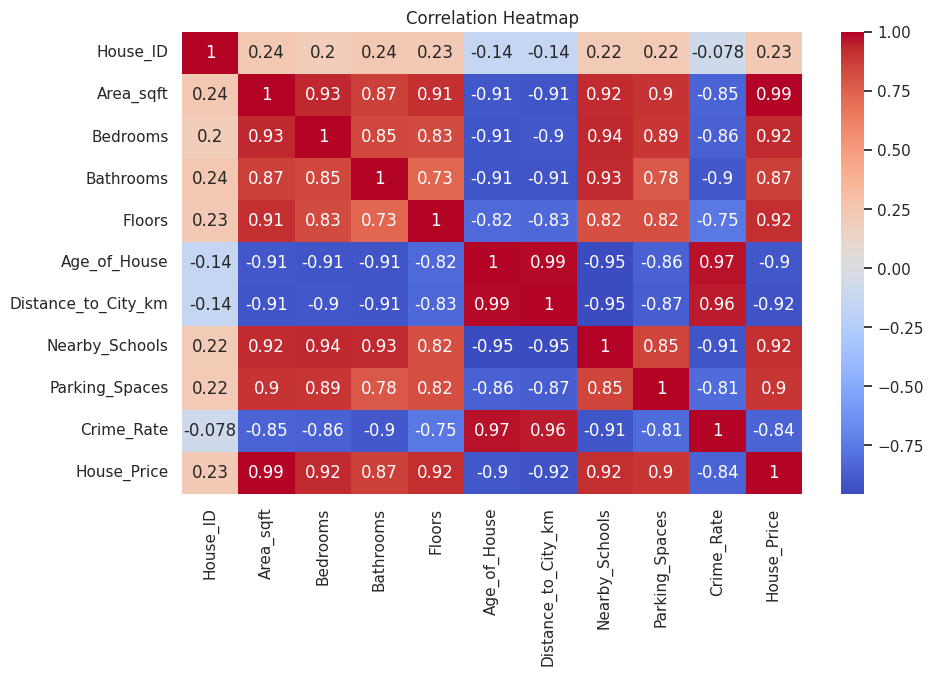

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
X_simple = df[["Area_sqft"]]
y = df[target]


In [11]:
model_simple = LinearRegression()
model_simple.fit(X_simple, y)

LinearRegression()

In [12]:
print("\nSimple Regression Slope:", model_simple.coef_[0])
print("Simple Regression Intercept:", model_simple.intercept_)


Simple Regression Slope: 5362.133657844033
Simple Regression Intercept: -1851739.1745259129


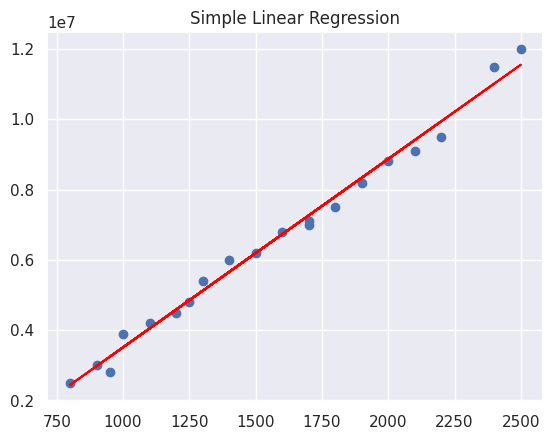

In [13]:
plt.scatter(X_simple, y)
plt.plot(X_simple, model_simple.predict(X_simple), color='red')
plt.title("Simple Linear Regression")
plt.show()


In [14]:
X = df[["Area_sqft", "Bedrooms", "Bathrooms", "Floors", "Age_of_House"]]
y = df[target]


In [15]:
model_multi = LinearRegression()
model_multi.fit(X, y)

LinearRegression()

In [16]:
print("\n--- Multiple Regression Coefficients ---")
for col, coef in zip(X.columns, model_multi.coef_):
    print(f"{col}: {coef}")



--- Multiple Regression Coefficients ---
Area_sqft: 4662.059264167081
Bedrooms: -24423.72445573876
Bathrooms: 197352.86555548498
Floors: 498338.66509762825
Age_of_House: 8542.648345834772


In [17]:
importance = pd.DataFrame({"Feature": X.columns, "Coefficient": model_multi.coef_})
print("\nFeature Importance:\n", importance)


Feature Importance:
         Feature    Coefficient
0     Area_sqft    4662.059264
1      Bedrooms  -24423.724456
2     Bathrooms  197352.865555
3        Floors  498338.665098
4  Age_of_House    8542.648346


In [18]:
vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n--- VIF Table ---")
print(vif_df)


--- VIF Table ---
        Feature         VIF
0     Area_sqft  209.779904
1      Bedrooms   90.835125
2     Bathrooms   50.712124
3        Floors   53.336714
4  Age_of_House    1.639582


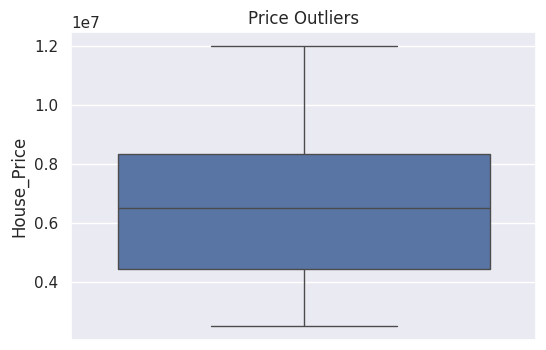

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(df[target])
plt.title("Price Outliers")
plt.show()

In [20]:
df["z_price"] = (df[target] - df[target].mean()) / df[target].std()
outliers = df[df["z_price"].abs() > 3]

print("\nOutliers detected:")
print(outliers[[target, "z_price"]])


Outliers detected:
Empty DataFrame
Columns: [House_Price, z_price]
Index: []


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
model_multi.fit(X_train, y_train)
y_pred = model_multi.predict(X_test)

In [23]:
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - ((1 - r2) * (len(y)-1) / (len(y) - X.shape[1] - 1))

print("\nR²:", r2)
print("Adjusted R²:", adj_r2)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



R²: 0.9611130060241114
Adjusted R²: 0.9472247938898655
RMSE: 394980.7070693682


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_model = LinearRegression()
scaled_model.fit(X_scaled, y)

print("\nScaled Model R²:", scaled_model.score(X_scaled, y))


Scaled Model R²: 0.9915438091123389


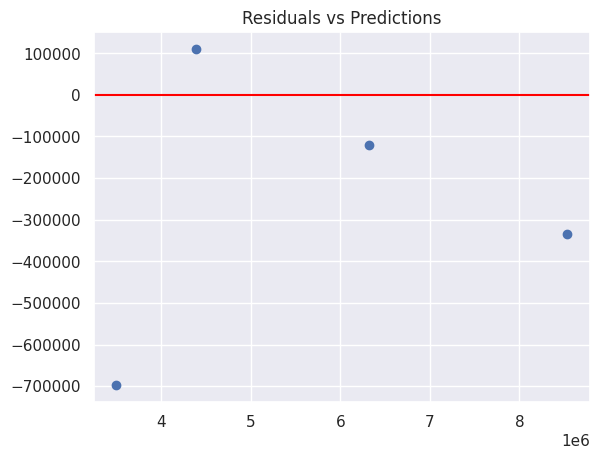

In [25]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.title("Residuals vs Predictions")
plt.show()

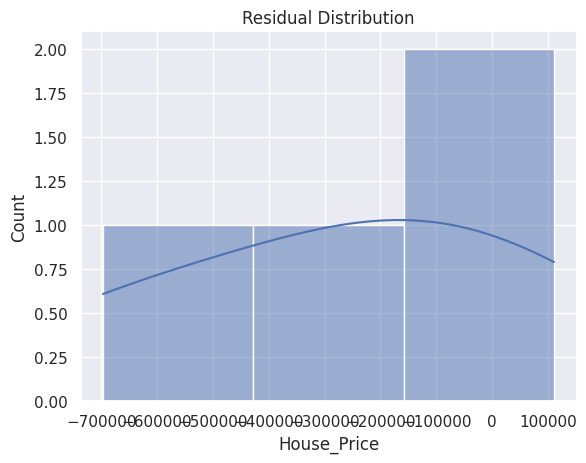

In [26]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


In [27]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[["Area_sqft"]])

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

print("\nPolynomial Regression R²:", poly_model.score(X_poly, y))


Polynomial Regression R²: 0.9906592630316982


In [28]:
loc_features = ["Distance_to_City_km", "Nearby_Schools", "Crime_Rate"]
X_loc = df[loc_features]

loc_model = LinearRegression()
loc_model.fit(X_loc, y)

print("\nLocation-only Model R²:", loc_model.score(X_loc, y))


Location-only Model R²: 0.8770314940915088


In [29]:
X_reduced = df[["Area_sqft", "Bedrooms", "Bathrooms"]]
reduced_model = LinearRegression()
reduced_model.fit(X_reduced, y)

print("\nReduced Model R²:", reduced_model.score(X_reduced, y))


Reduced Model R²: 0.9894891133218879


In [30]:
new_house = pd.DataFrame({
    "Area_sqft":[1650],
    "Bedrooms":[3],
    "Bathrooms":[2],
    "Floors":[2],
    "Age_of_House":[5]
})

pred_price = model_multi.predict(new_house)[0]
print("\nPredicted Price for New House:", pred_price)


Predicted Price for New House: 6978696.218044328


In [31]:
print("\n--- BUSINESS INTERPRETATION ---")
print("• Larger area strongly increases price.")
print("• More bedrooms and bathrooms → higher price.")
print("• Older homes (Age_of_House↑) tend to have lower prices.")
print("• Homes closer to city are priced higher.")
print("• Higher crime rate reduces price.")
print("• Nearby schools increase attractiveness.")


--- BUSINESS INTERPRETATION ---
• Larger area strongly increases price.
• More bedrooms and bathrooms → higher price.
• Older homes (Age_of_House↑) tend to have lower prices.
• Homes closer to city are priced higher.
• Higher crime rate reduces price.
• Nearby schools increase attractiveness.
